# Goal

Decomposite the orbital decay curve into trend and seasonal components usint Lomb-Scargle and STL.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from utils.data_loader import find_repo_root
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from utils.data_loader import load_parquet
from utils.plot_loader import plot_lombscargle_periodogram

# Data

In [2]:
# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


Lets have a look at the raw data:

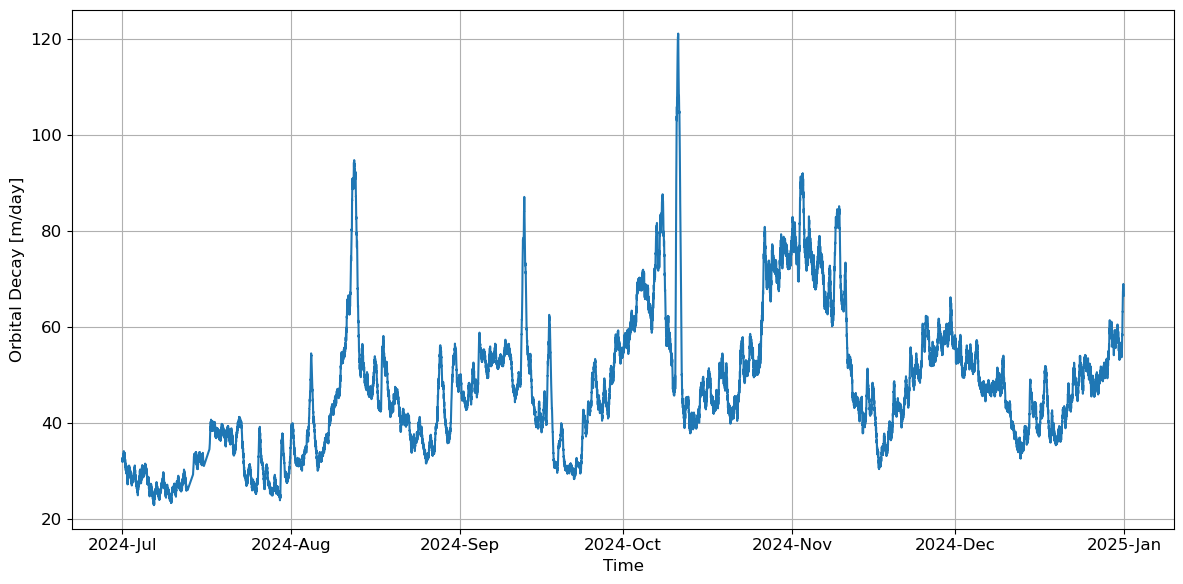

In [3]:
from utils.plot_loader import plot_orbital_decay

# =========================== Input ===================================
start_date = '2024-07-01 00:00:00'
end_date = '2025-01-01 00:00:00'
# start_date = pd.to_datetime(GFOC_data['time'].iloc[0])
# end_date = pd.to_datetime(GFOC_data['time'].iloc[-1]) #removed gap by ignoring the last 4321 values (for csv)

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=Flags)

# STL filter

In [4]:
def stl_decomposition(y, day):
    period = int(day * 24 * 60 * 3) # 1: 22.77 days, 2: 
    print(f"using a period of {period/(180*24)} days")
    seasonal = 100 * period + ((100*period % 2) == 0)  # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period + 1))
    trend_jump = int(0.15 * 1.5 * (period + 1))


    mod = STL(
        y['orbital_decay'],
        period=period,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
        seasonal_deg=0,
        robust=True
    )
    %timeit mod.fit()
    res = mod.fit()

    # plot
    plt.rc("figure", figsize=(12, 10))
    plt.rc("font", size=13)
    fig = res.plot()
    return res

## 1. Remove trend using STL decomposition

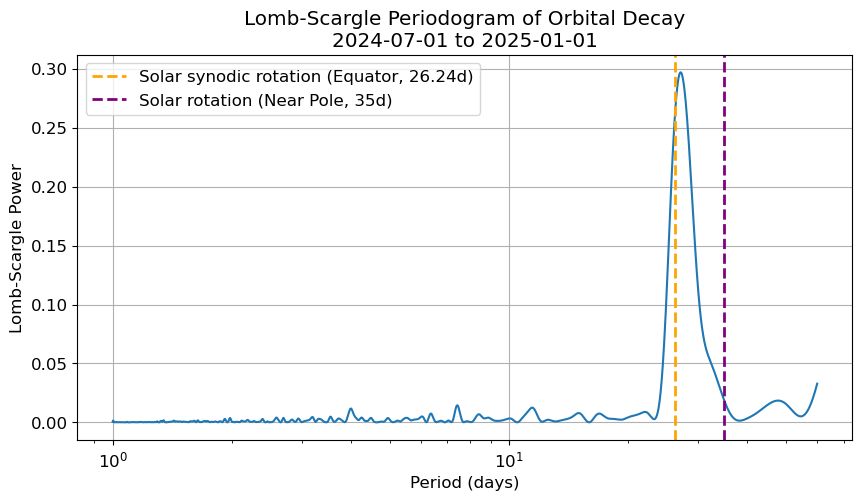

1. Period: 27.1336 +2.3879 -1.8297 days
2. Period: 47.8132 +4.3561 -5.0649 days
3. Period: 7.4105 +0.1256 -0.1180 days
4. Period: 11.4534 +0.3375 -0.4784 days
5. Period: 3.9926 +0.0795 -0.0637 days
6. Period: 22.0647 +0.8319 -1.9905 days
7. Period: 15.0060 +0.4721 -0.6807 days
8. Period: 6.3575 +0.0910 -0.0828 days
9. Period: 16.9126 +0.7714 -0.5154 days
10. Period: 8.4011 +0.2492 -0.1786 days


In [5]:
# Use time as index for y
GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)].copy()
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

using a period of 7.409953703703704 days
55.8 s ± 1.57 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


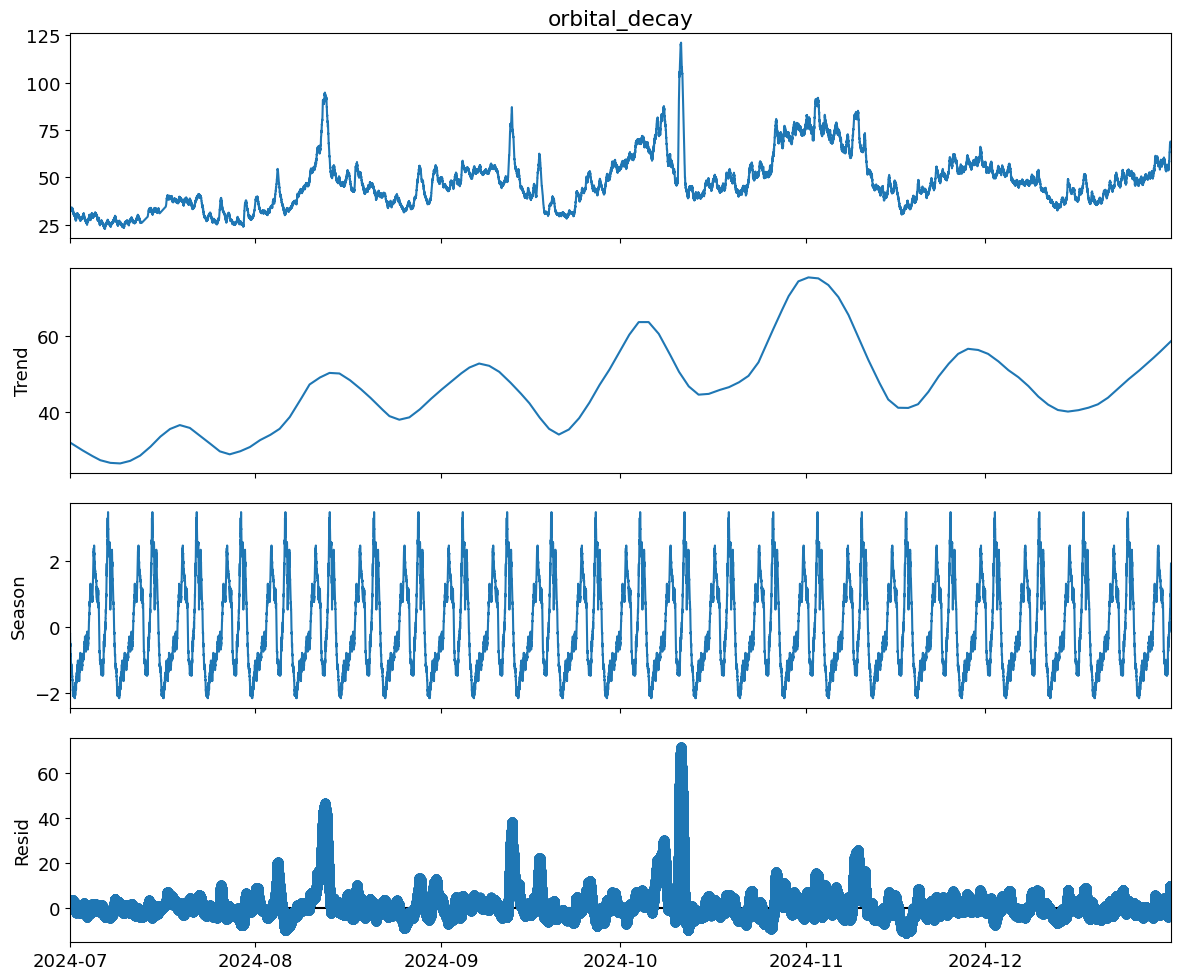

In [6]:
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()


res_1 = stl_decomposition(y, 7.41)

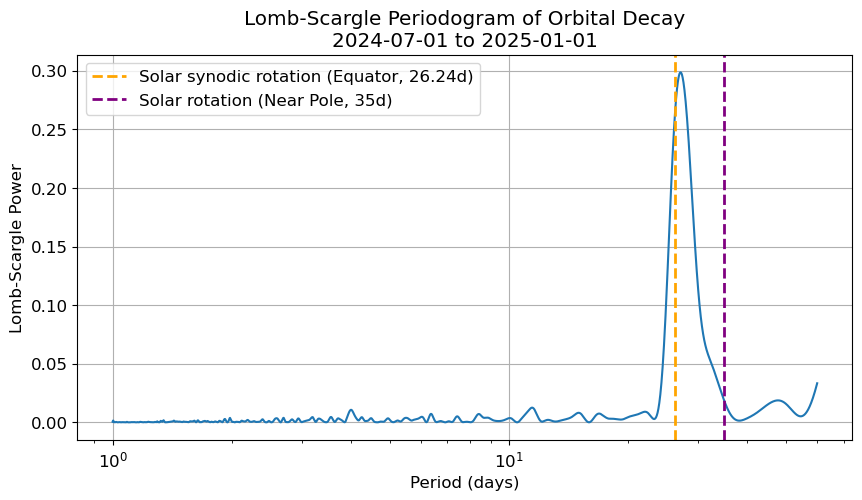

1. Period: 27.1263 +2.3968 -1.8350 days
2. Period: 47.7908 +4.3553 -5.0784 days
3. Period: 11.4483 +0.3363 -0.4839 days
4. Period: 3.9979 +0.0906 -0.0795 days
5. Period: 22.0647 +0.8359 -2.0261 days
6. Period: 15.0015 +0.4697 -0.6742 days
7. Period: 16.8958 +0.7615 -0.5091 days
8. Period: 6.3635 +0.0935 -0.0853 days
9. Period: 8.3983 +0.5370 -0.1779 days
10. Period: 7.4073 +0.1207 -0.1132 days


In [7]:
# GFOC_subset['trend_1'] = res_1.trend.values
GFOC_subset['seasonal_1'] = res_1.seasonal.values
GFOC_subset['residual'] = res_1.resid.values + res_1.trend.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']
# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

## 2. Remove Periodic Signal and non-linear Trend

using a period of 27.12986111111111 days
58.6 s ± 118 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


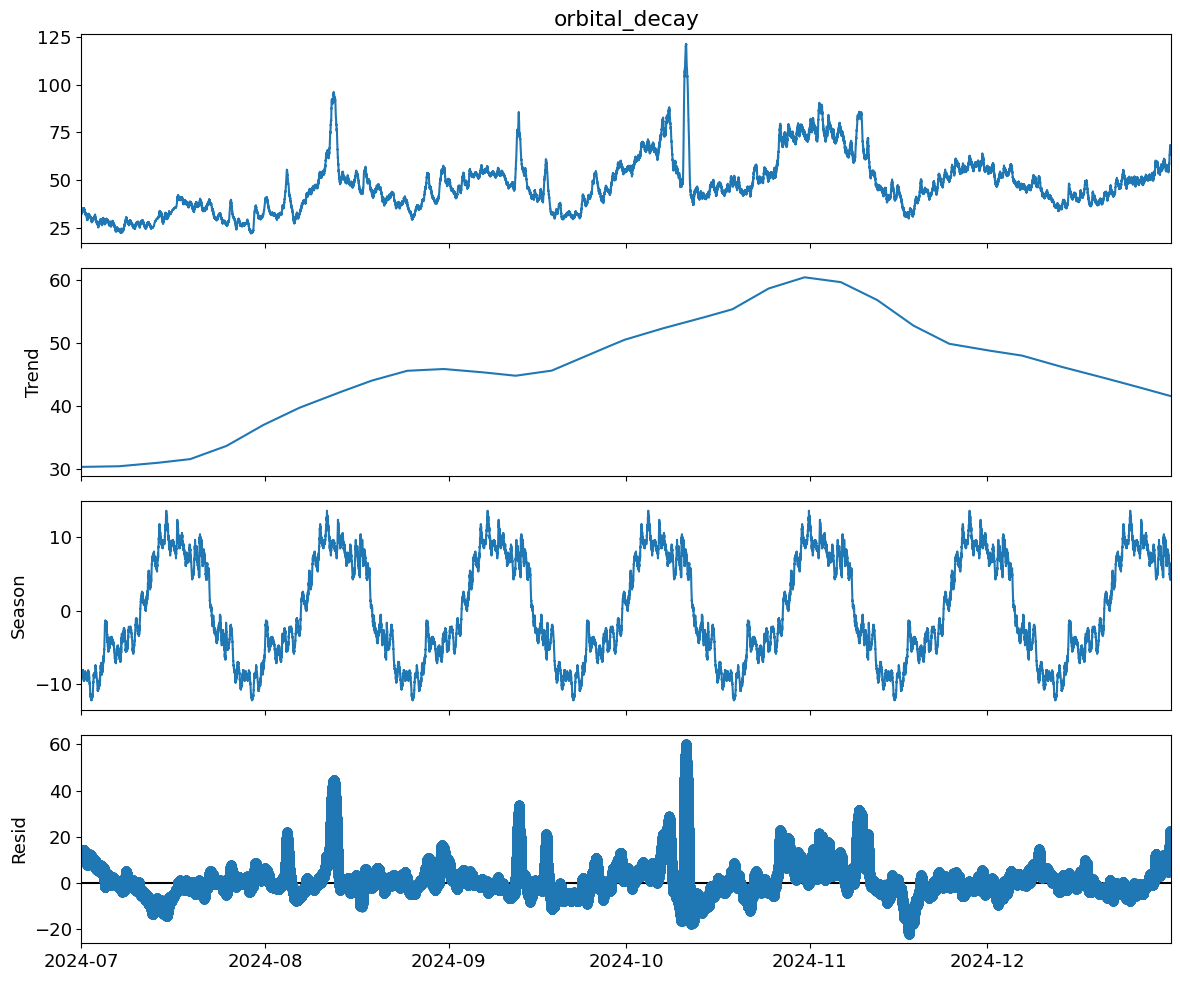

In [8]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_2 = stl_decomposition(y, 27.13)

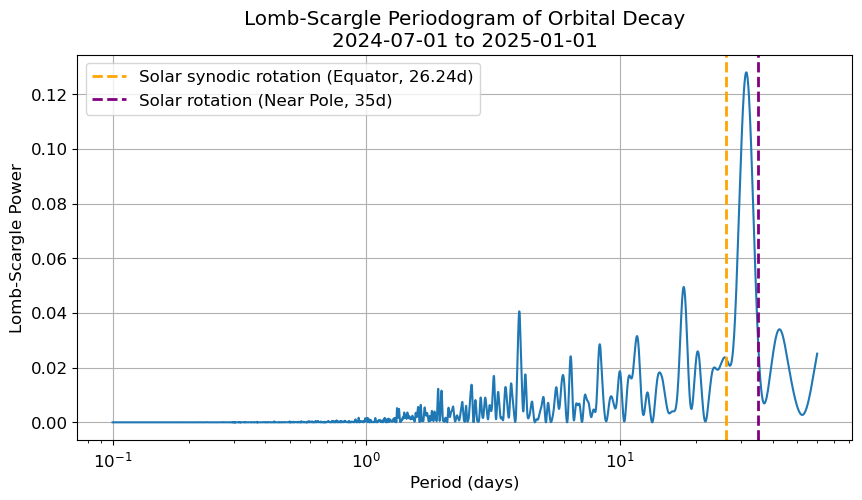

1. Period: 31.5043 +2.4653 -2.3815 days
2. Period: 17.8567 +0.6650 -0.6739 days
3. Period: 4.0148 +0.0770 -0.0696 days
4. Period: 42.6341 +4.4006 -3.6504 days
5. Period: 11.6887 +0.3657 -0.9060 days
6. Period: 8.3337 +0.2064 -0.1831 days
7. Period: 20.2788 +0.7021 -0.6747 days
8. Period: 6.4006 +0.0939 -0.1006 days
9. Period: 25.9535 +10.1558 -3.3398 days
10. Period: 23.5716 +12.7334 -1.0595 days


In [9]:
GFOC_subset['trend_1'] = res_2.trend.values
GFOC_subset['seasonal_2'] = res_2.seasonal.values
GFOC_subset['residual'] = res_2.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=60,  # days
    show=False
)

## 3. Remove secondary seasonal components

using a period of 31.5 days
1min 1s ± 1.02 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


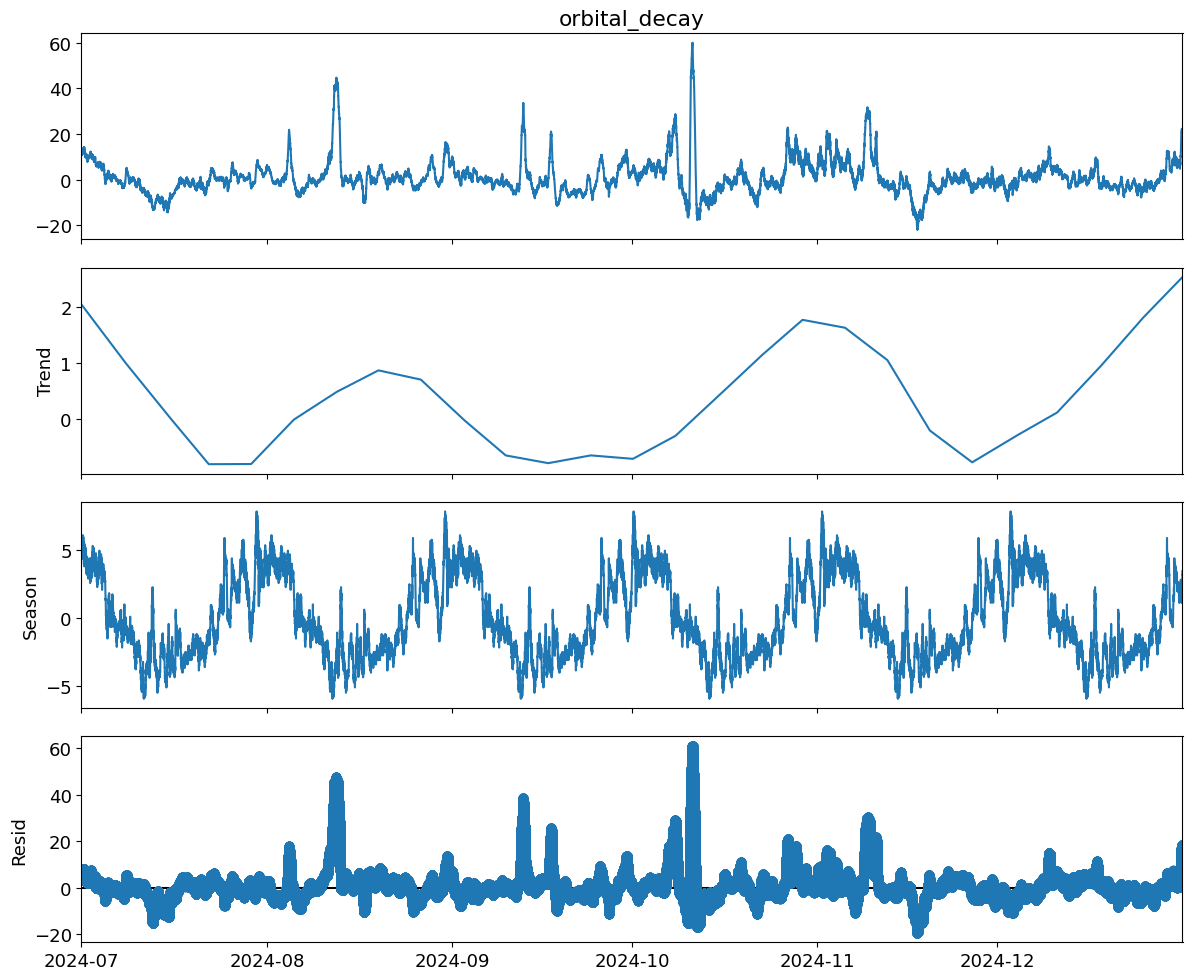

In [10]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_3 = stl_decomposition(y, 31.5)

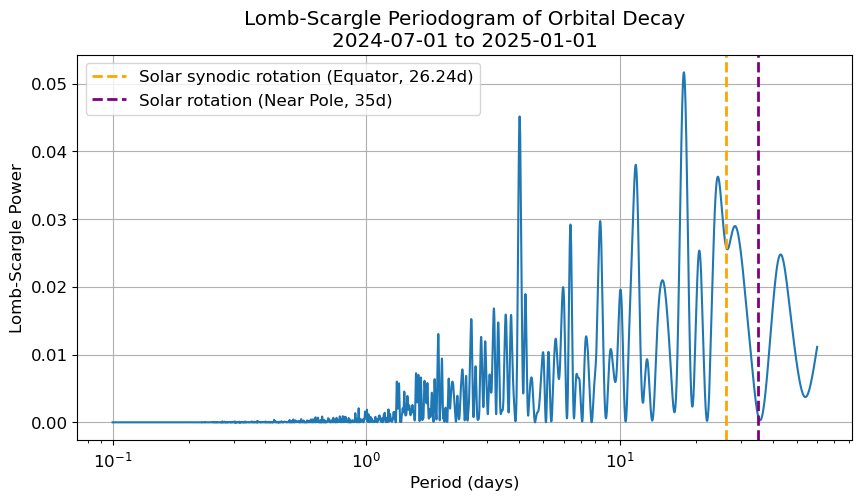

1. Period: 17.8886 +0.7002 -0.7058 days
2. Period: 4.0261 +0.0687 -0.0637 days
3. Period: 11.5539 +0.3934 -0.5581 days
4. Period: 24.3746 +6.9931 -1.2919 days
5. Period: 8.3685 +0.2047 -0.2245 days
6. Period: 6.3884 +0.0980 -0.1003 days
7. Period: 28.4608 +3.5848 -5.5366 days
8. Period: 20.5704 +0.7350 -0.6939 days
9. Period: 43.0002 +5.3693 -3.8642 days
10. Period: 14.7315 +1.0081 -0.8185 days


In [11]:
GFOC_subset['trend_2'] = res_3.trend.values
GFOC_subset['seasonal_3'] = res_3.seasonal.values
GFOC_subset['residual'] = res_3.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=60,  # days
    show=False
)

# Plot Results

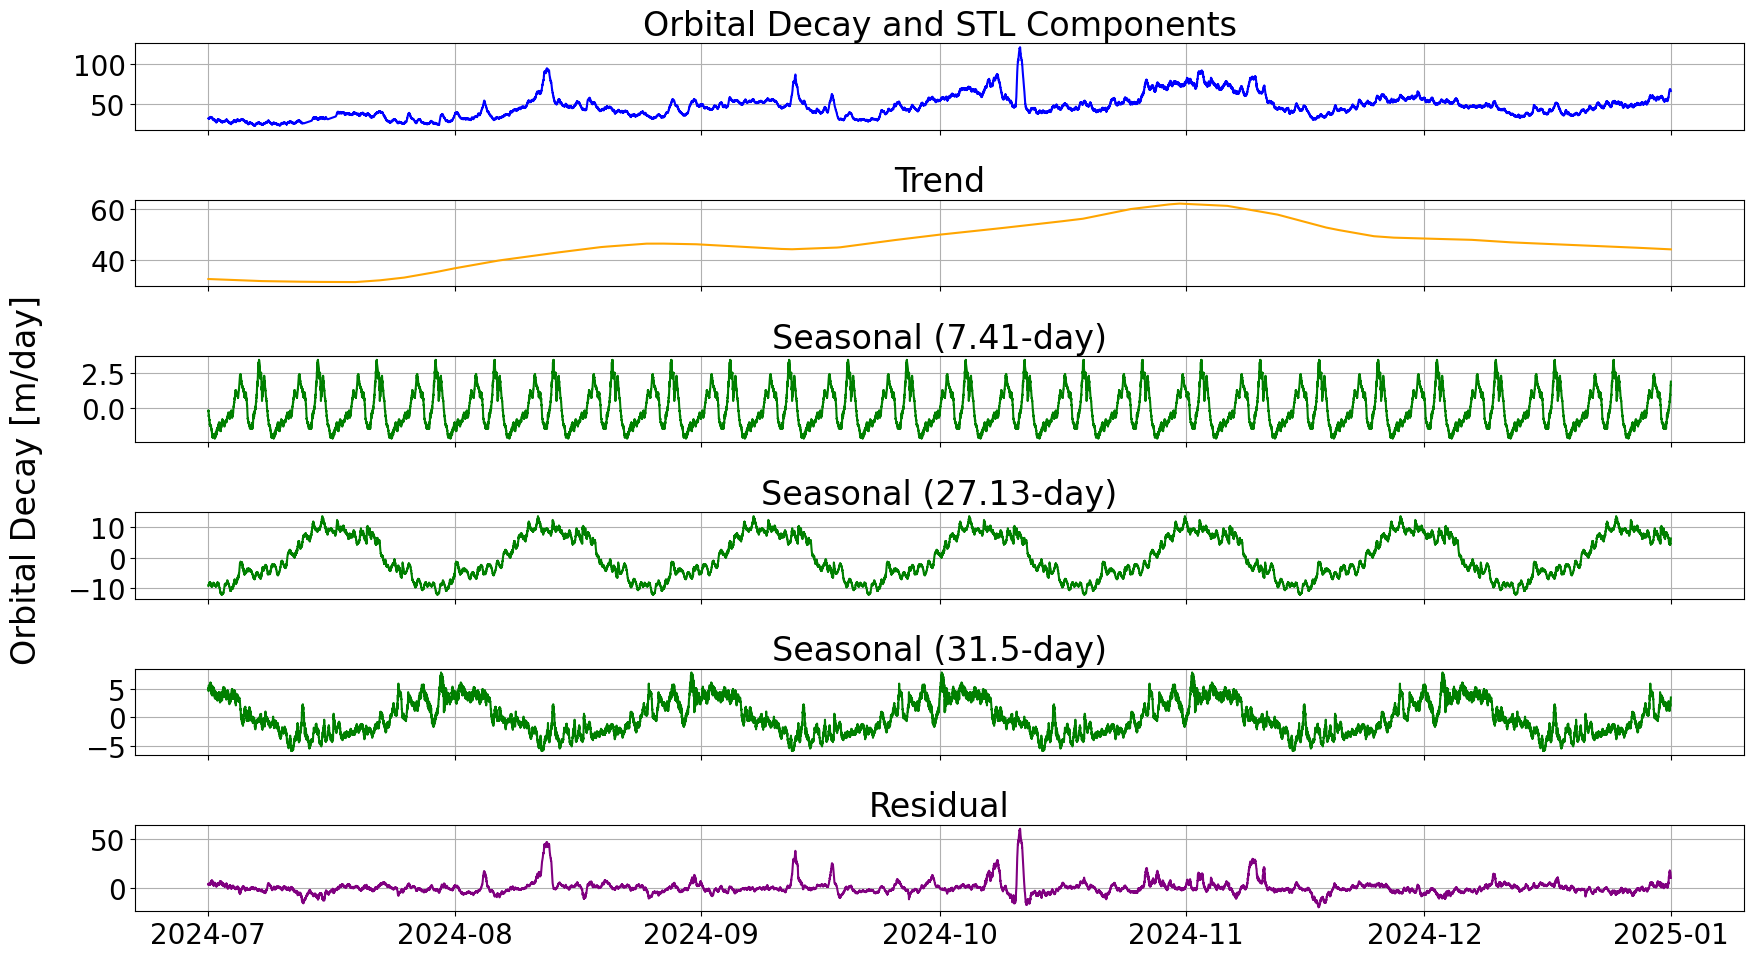

In [12]:
# set font & label size
plt.rcParams.update({'font.size': 20})

GFOC_subset['original_decay'] = GFOC_data['orbital_decay'].where(GFOC_data['time'].isin(GFOC_subset['time']))
# plot components
fig, axs = plt.subplots(6, 1, figsize=(18, 10), sharex=True)
axs[0].plot(GFOC_subset['time'], GFOC_subset['original_decay'], color='blue')
axs[0].set_title('Orbital Decay and STL Components')

axs[1].plot(GFOC_subset['time'], GFOC_subset['trend_1'] + GFOC_subset['trend_2'], color='orange')
axs[1].set_title('Trend')

axs[2].plot(GFOC_subset['time'], GFOC_subset['seasonal_1'], color='green')
axs[2].set_title('Seasonal (7.41-day)')

axs[3].plot(GFOC_subset['time'], GFOC_subset['seasonal_2'], color='green')
axs[3].set_title('Seasonal (27.13-day)')

axs[4].plot(GFOC_subset['time'], GFOC_subset['seasonal_3'], color='green')
axs[4].set_title('Seasonal (31.5-day)')

axs[5].plot(GFOC_subset['time'], GFOC_subset['residual'], color='purple')
axs[5].set_title('Residual')

for ax in axs:
    # ax.legend()
    ax.grid()
# plt.xlabel('time')
fig.supylabel('Orbital Decay [m/day]')
plt.tight_layout()
plt.show()

In [13]:
print("Trend:")
trend = GFOC_subset['trend_1'] + GFOC_subset['trend_2']
print(f"Start value: {trend.iloc[0]:.2f}, End value: {trend.iloc[-1]:.2f}")
max_idx = trend.idxmax()
max_time = max_idx if isinstance(max_idx, pd.Timestamp) else GFOC_subset.loc[max_idx, 'time']
print(f"Max value: {trend.max():.2f} at time: {max_time}")

Trend:
Start value: 32.42, End value: 44.14
Max value: 62.23 at time: 2024-10-31 02:00:00
